First 5 Rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBe

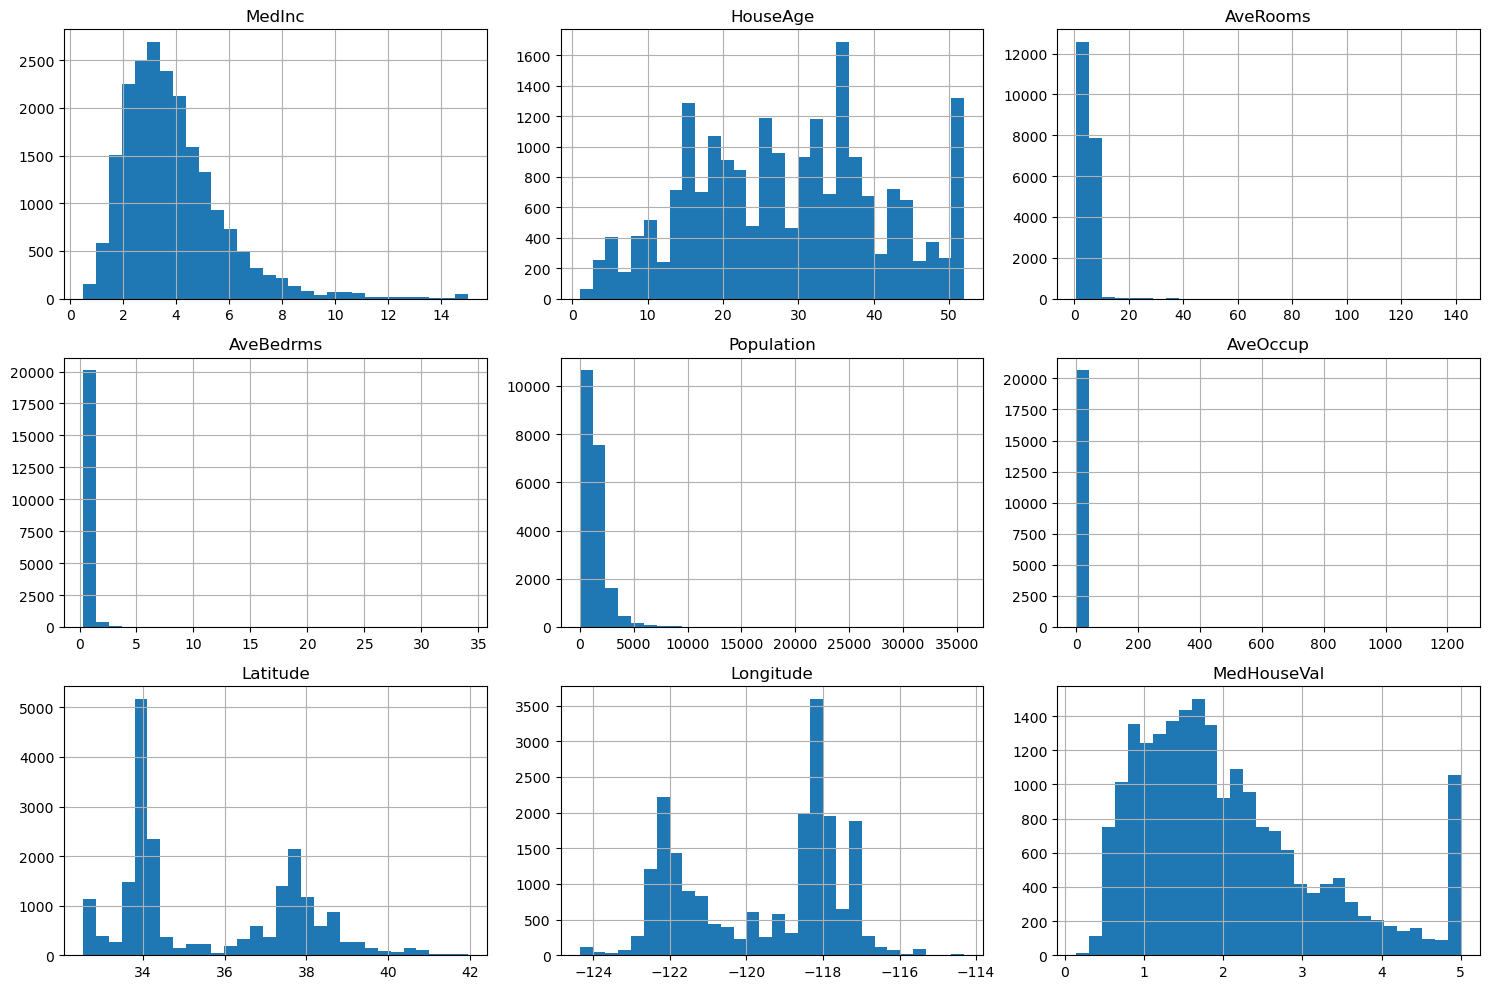

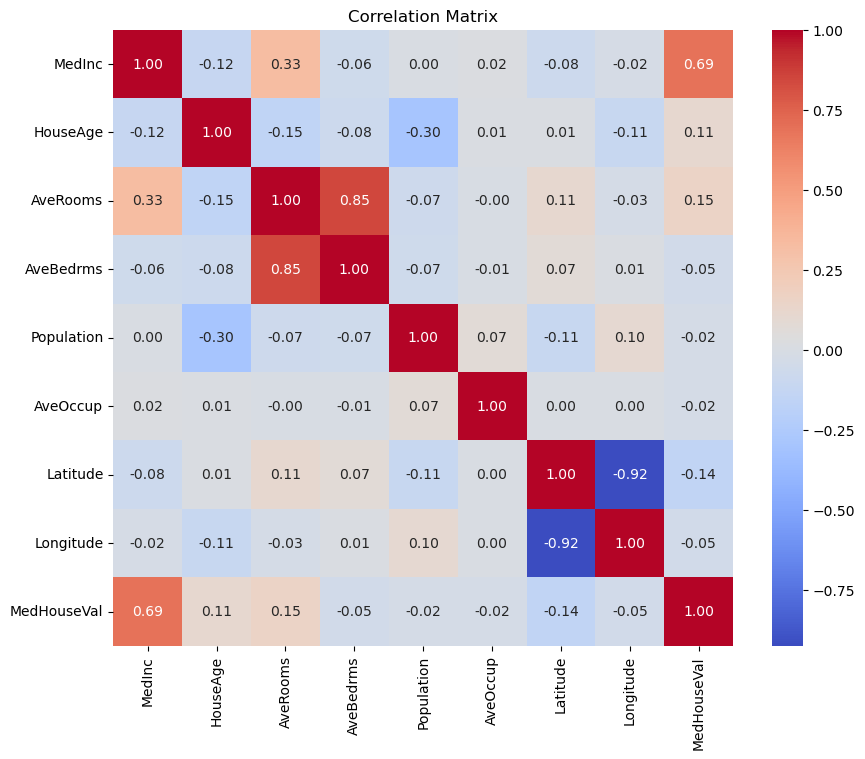

Correlation with Target Variable:

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("First 5 Rows of Dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

print("Missing Values:\n")
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())
print("Dataset Shape:", df.shape)
print(df.describe())

df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

correlation = df.corr()['MedHouseVal'].sort_values(ascending=False)

print("Correlation with Target Variable:\n")
print(correlation)

## Preprocessing Steps and Justification

### 1. Missing Value Handling

The dataset was checked for missing values using the `isnull().sum()` function. No missing values were found in the California Housing dataset. However, a mean imputation step was included as a standard preprocessing practice to ensure the dataset could be handled correctly if missing values were present in future versions or similar datasets.

**Why it is necessary:**

* Missing values can cause machine learning algorithms to fail or produce inaccurate predictions.
* Imputation helps preserve data instead of removing records and potentially losing valuable information.

### 2. Feature Scaling

Feature scaling was performed using **Standardization** with Scikit-learn's `StandardScaler`.

Standardization transforms each feature so that it has:

* Mean = 0
* Standard Deviation = 1

**Why Standardization was chosen:**

* The features in the dataset have different ranges. For example, `Population` can contain values in the thousands, while `HouseAge` has much smaller values.
* Algorithms such as Support Vector Regression (SVR) are sensitive to feature scales and perform better when all features are on a similar scale.
* Standardization prevents features with larger numeric ranges from dominating the learning process.

### 3. Exploratory Data Analysis (EDA)

EDA was conducted to better understand the dataset before model training.

The following analyses were performed:

* Examination of dataset shape and structure.
* Summary statistics using `describe()`.
* Distribution analysis using histograms.
* Correlation analysis using a heatmap.
* Investigation of relationships between features and the target variable (`MedHouseVal`).

**Why EDA is necessary:**

* It helps identify patterns, trends, and potential anomalies in the data.
* It provides insights into feature distributions and relationships.
* Correlation analysis helps determine which features have stronger influence on house prices.
* Understanding the dataset improves model selection and interpretation of results.

### Key Findings from EDA

* `MedInc` (Median Income) has the strongest positive correlation with the target variable (`MedHouseVal`), indicating that areas with higher income generally have higher house prices.
* Geographic features such as `Latitude` and `Longitude` influence housing prices, reflecting location-based price variations.
* The dataset contains features with different scales, supporting the need for feature standardization.
* Most features show moderate correlations, suggesting limited multicollinearity issues.

### Conclusion

The preprocessing steps ensured that the dataset was clean, properly scaled, and thoroughly explored before model training. These steps improve model reliability, enhance algorithm performance, and provide a better understanding of the factors affecting housing prices in California.
